In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath('../scripts'))
from supporting.load_data import load_data, build_data_loaders, x_scale, y_scale, y_unscale
from sklearn import metrics
from torch import nn, optim
import torch.nn.functional as F

In [2]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device

In [3]:
import mlflow
from mlflow.tracking import MlflowClient

In [4]:
import os
os.environ["DATABRICKS_CONFIG_FILE"] = "../secrets/.databrickscfg"

mlflow.login(interactive=False)
print("MLflow login successful.")

2026/03/20 15:13:22 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://dbc-d0177b72-9a40.cloud.databricks.com.


MLflow login successful.


In [5]:
import mlflow
import json
from mlflow.tracking import MlflowClient

def load_model_artifacts(model_uuid, dst_path):

    client = MlflowClient()

    exp = client.get_experiment_by_name(
        "/Users/harish.akula096@gmail.com/regressors"
    )
    experiment_id = exp.experiment_id

    runs = mlflow.search_runs(
        experiment_ids=[experiment_id],
        filter_string=f"tags.mlflow.runName = '{model_uuid}'"
    )

    run_id = runs.iloc[0]["run_id"]

    weights_path = client.download_artifacts(
        run_id,
        f"{model_uuid}.best_weights.pt",
        dst_path=dst_path
    )

    config_path = client.download_artifacts(
        run_id,
        "config.json",
        dst_path=dst_path
    )

    with open(config_path) as f:
        config = json.load(f)

    return weights_path, config

# weights_path, config = load_model_artifacts("y25y26m1", "./artifacts")

In [6]:
# config["data_dir"] = "/scratch/akula.ha/dataset"

In [7]:
# config = {
#     "model_type": "skip-mini",
#     "input_shape": 4,
#     "amplitude_shape": 36,
#     "data_dir": "/scratch/hakula/dataset",
#     "seed": 42,
#     "var_y": [
#         "y5",
#         "y6"
#     ],
#     "use_MC_sample": True,
#     "train-sample-size": 10000000,
#     "validate-sample-size": 500000,
#     "test-sample-size": 500000,
#     "activation": "leaky_relu",
#     "width": 30,
#     "depth": 12,
#     "skip_block_layers": 5,
#     "lr_decay_type": "plateau",
#     "initial_lr": 0.001,
#     "lr_patience": 10,
#     "lr_factor": 0.8,
#     "lr_delta": 7e-05,
#     "batch_size": 1024,
#     "steps_per_epoch": 2400,
#     "early_stopping_start_epoch": 150,
#     "patience": 25,
#     "loss": "huber",
#     "base_directory": "../models/",
#     "epochs": 2000,
#     "model-uuid": "UUID",
#     "train-samples-used": 6,
#     "validate-samples-used": 6,
#     "test-samples-used": 6,
#     "n_targets": 2
# }

In [8]:
torch.set_default_dtype(torch.float64)

In [9]:
class MyDataset(torch.utils.data.Dataset):
    '''Class to convert dataframe to torch tensor'''
    def __init__(self, x, y, config):
        x = x.copy(deep=True)
        y = y.copy(deep=True)

        # Vectorized scaling (if applicable)
        x['x1'] = x_scale(x['x1'])  # Or use apply if x_scale isn't vectorized

        # Number of targets
        config['n_targets'] = y.shape[1]

        for column in y.columns:
            y[column] = y[column].apply(y_scale)

        device = get_device()
        self.x = torch.tensor(x.values, dtype=torch.float64).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

df, spark = load_data(config)

# x_cols = ['x1', 'x2', 'x3', 'x4']
# y_cols = config["var_y"]
# x_train = df["train"][x_cols]
# y_train = df["train"][y_cols]
# x_val = df["validate"][x_cols]
# y_val = df["validate"][y_cols]
# x_test = df["test"][x_cols]
# y_test = df["test"][y_cols]

# train_dataset = MyDataset(x_train, y_train, config)
# val_dataset   = MyDataset(x_val, y_val, config)
# test_dataset  = MyDataset(x_test, y_test, config)

# # load the data into torch tensor batches
# batch_size = config["batch_size"]
# numworkers = 4 if get_device().type == 'cpu' else 0

# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
# val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=numworkers, drop_last=True)


NameError: name 'config' is not defined

In [23]:
model_path = weights_path # "/home/hakula/qqzz4l-NN/models/skip-mini_ff414e9e_30_12_5/ff414e9e.best_weights.pt"

NameError: name 'weights_path' is not defined

In [24]:
from sklearn.metrics import r2_score

def safe_mape(y_true, y_pred, eps=1e-6):
    """
    Mean Absolute Percentage Error with denominator guard.
    Adds eps to denominator to avoid blow-up near zero.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))


def _percent_delta(y_true, y_pred, eps=1e-6):
    """
    Percentage delta with epsilon guard:
    (y_pred - y_true) / (y_true + eps) * 100
    """
    return (y_pred - y_true) / (y_true + eps) * 100.0


def _plot_error_histograms(delta_matrix, labels, cutoff=5, title="Error Histogram Overlay"):
    """Overlay histogram for each target column in delta_matrix."""
    plt.figure(figsize=(8, 5))
    for j, name in enumerate(labels):
        col = delta_matrix[:, j]
        m = np.isfinite(col)
        if cutoff is not None:
            m &= (np.abs(col) < cutoff)
        data = col[m]
        if data.size == 0:
            continue
        plt.hist(data, bins=100, histtype='step', label=name, density=True)
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.xlabel(r'$\delta$ (%)')
    plt.ylabel('pdf')
    plt.title(title)
    plt.legend()
    plt.show()


def evaluate_model(model, dataloader, device, config, eps=1e-6):
    """
    Evaluate a trained model and display metrics and histograms.
    eps: small constant to stabilize denominators in MAPE and deltas.
    """
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            pred = model(xb).cpu()
            all_preds.append(pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()

    y_names = config["var_y"]
    assert y_true.ndim == 2 and y_true.shape[1] == len(y_names)

    # --- Scaled metrics ---
    scaled = {}
    overall_mape = safe_mape(y_true, y_pred, eps=eps)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    # --- Unscaled metrics ---
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    # --- Print results ---
    print("\n=== Evaluation (SCALED) ===")
    print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    print("\n=== Evaluation (UNSCALED) ===")
    print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    # --- Histograms ---
    scaled_delta   = _percent_delta(y_true, y_pred, eps=eps)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un, eps=eps)

    _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Errors")
    _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Errors")

    return scaled, unscaled

In [25]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # # plot all the scaled and real deltas
    # for c in scaled_delta_cname:
    #     make_error_plot(config, df_pred, col=c)
    # for c in delta_cname:
    #     make_error_plot(config, df_pred, col=c)
        
    test_metrics = {}
    test_metrics['r2'] = {}
    test_metrics['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        test_metrics['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        test_metrics['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars]).mean()
    
    test_metrics['r2']['model'] = r2_score
    test_metrics['abs_score']['model'] = abs_score
    
    return test_metrics, df_pred


In [26]:
def get_activation(activation_str):
    if activation_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif activation_str == 'relu':
        return nn.ReLU()
    if activation_str == 'softplus':
        return nn.Softplus()
    if activation_str == 'swish':
        return nn.SiLU()
    if activation_str == 'sigmoid':
        return nn.Sigmoid()
    if activation_str == 'tanh':
        return nn.Tanh()
    if activation_str == 'prelu':
        return nn.PReLU()
    if activation_str == 'elu':
        return nn.ELU()

# Residual module (equivalent to 'module' in Keras)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, width, n_skip_layers, activation='swish'):
        super().__init__()
        layers = []
        orig_in_dim = in_dim
        for _ in range(n_skip_layers - 1):
            layers.append(nn.Linear(in_dim, width))
            layers.append(get_activation(activation))
            in_dim = width
        layers.append(nn.Linear(width, orig_in_dim))  # projection back to input dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.net(x)

# Full model (equivalent to 'model' in Keras)
class SkipModel(nn.Module):
    def __init__(self, input_dim, width, depth, n_skip_layers, output_dim, activation='swish'):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            get_activation(activation)
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(in_dim=width, width=width, n_skip_layers=n_skip_layers, activation=activation) for _ in range(depth)
        ])
        self.output_layer = nn.Linear(width, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)


In [29]:
MODEL_PAIRS = ["y1y2", "y3y4"]
MODEL_SEEDS = [1, 2, 3]
ARTIFACT_ROOT = "./artifacts"
DATA_DIR = "/scratch/akula.ha/dataset"
OUTLIER_STD = 5.0

all_results = {}

for pair in MODEL_PAIRS:
    print(f"\n{'#' * 80}")
    print(f"Preparing evaluation pipeline for pair: {pair}")
    print(f"Seeds to evaluate: {MODEL_SEEDS}")
    print(f"{'#' * 80}")

    pair_bootstrap_uuid = f"{pair}m{MODEL_SEEDS[0]}"
    _, pair_config = load_model_artifacts(pair_bootstrap_uuid, ARTIFACT_ROOT)
    pair_config["data_dir"] = DATA_DIR

    print(f"Loading dataset for {pair} using bootstrap model {pair_bootstrap_uuid}")
    df, spark = load_data(pair_config)

    x_cols = ['x1', 'x2', 'x3', 'x4']
    y_cols = pair_config["var_y"]

    test_df = df["test"].copy(deep=True)
    filtered_test_df = filter_test_dataframe(
        test_df,
        y_cols,
        outlier_std=OUTLIER_STD,
    )
    print(
        f"{pair}: filtered test rows {len(test_df)} -> {len(filtered_test_df)} "
        f"using {OUTLIER_STD} std"
    )
    print(f"Building shared test loader for {pair}")

    pair_test_dataset = MyDataset(
        filtered_test_df[x_cols],
        filtered_test_df[y_cols],
        pair_config,
    )
    batch_size = pair_config["batch_size"]
    numworkers = 4 if get_device().type == 'cpu' else 0
    pair_test_loader = torch.utils.data.DataLoader(
        pair_test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=numworkers,
        drop_last=False,
    )

    all_results[pair] = {}
    pair_checkpoint_paths = []

    for seed in MODEL_SEEDS:
        model_uuid = f"{pair}m{seed}"
        print(f"\n{'=' * 80}")
        print(f"Running single-model evaluation for {model_uuid}")
        print(f"{'=' * 80}")

        weights_path, seed_config = load_model_artifacts(model_uuid, ARTIFACT_ROOT)
        seed_config["data_dir"] = DATA_DIR
        pair_checkpoint_paths.append(weights_path)
        print(f"Loaded artifacts for {model_uuid}")

        width = seed_config['width']
        depth = seed_config['depth']
        n_skip_layers = seed_config['skip_block_layers']
        activation = seed_config['activation']

        seed_model = SkipModel(
            seed_config["input_shape"],
            width,
            depth,
            n_skip_layers,
            len(seed_config["var_y"]),
            activation,
        )
        seed_model.to(device=get_device())
        seed_model.load_state_dict(
            torch.load(
                weights_path,
                map_location=torch.device(
                    'cuda' if torch.cuda.is_available() else 'cpu'
                ),
            )
        )

        test_metrics, df_pred = test_model(seed_model, pair_test_loader, seed_config)
        scaled_metrics, unscaled_metrics = evaluate_model(
            seed_model, pair_test_loader, get_device(), seed_config, eps=0
        )
        print(f"Completed single-model evaluation for {model_uuid}")

        all_results[pair][seed] = {
            "model_uuid": model_uuid,
            "config": seed_config,
            "filtered_test_df": filtered_test_df.copy(deep=True),
            "test_metrics": test_metrics,
            "scaled_metrics": scaled_metrics,
            "unscaled_metrics": unscaled_metrics,
            "df_pred": df_pred,
        }

    print(f"\n{'=' * 80}")
    print(f"Running ensemble evaluation for pair {pair}")
    print(f"{'=' * 80}")
    all_results[pair]["ensemble"] = run_ensemble_evaluation(
        test_df=filtered_test_df,
        checkpoint_paths=pair_checkpoint_paths,
        config=pair_config,
        dataloader=pair_test_loader,
        eps=0,
    )
    print(f"Completed all evaluations for pair {pair}")



################################################################################
Preparing evaluation pipeline for pair: y1y2
Seeds to evaluate: [1, 2, 3]
################################################################################


Loading dataset for y1y2 using bootstrap model y1y2m1


ERROR:root:KeyboardInterrupt while sending command.               (1 + 45) / 46]
Traceback (most recent call last):
  File "/home/akula.ha/.conda/envs/myenv/lib/python3.9/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/akula.ha/.conda/envs/myenv/lib/python3.9/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/home/akula.ha/.conda/envs/myenv/lib/python3.9/socket.py", line 704, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 

In [8]:
width = config['width']
depth = config['depth']
n_skip_layers = config['skip_block_layers']
activation = config['activation']

model = SkipModel(config["input_shape"], width, depth, n_skip_layers, len(y_cols), activation)
model.to(device=get_device())

NameError: name 'config' is not defined

In [15]:
best_weights_path = model_path
model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

/tmp/ipykernel_181557/3790447714.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if 

<All keys matched successfully>

In [16]:
test_metrics, df_pred = test_model(model, test_loader, config)

In [17]:
test_metrics

{'r2': {'y25': 99.98847694218588,
  'y26': 99.99705700750198,
  'model': 99.99552224877455},
 'abs_score': {'y25': 99.60332514339323,
  'y26': -95.26364434155298,
  'model': 2.6306563767478752}}


=== Evaluation (SCALED) ===
Overall MAPE: 0.973693
Overall R2  : 0.999955
Overall Abs : 2.630656
y25: MAPE=0.003214, R2=0.999970, abs=99.678572
y26: MAPE=1.944173, R2=0.999940, abs=-94.417259

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.978302
Overall R2  : 0.999928
Overall Abs : 2.169840
y25: MAPE=0.003967, R2=0.999885, abs=99.603325
y26: MAPE=1.952636, R2=0.999971, abs=-95.263644


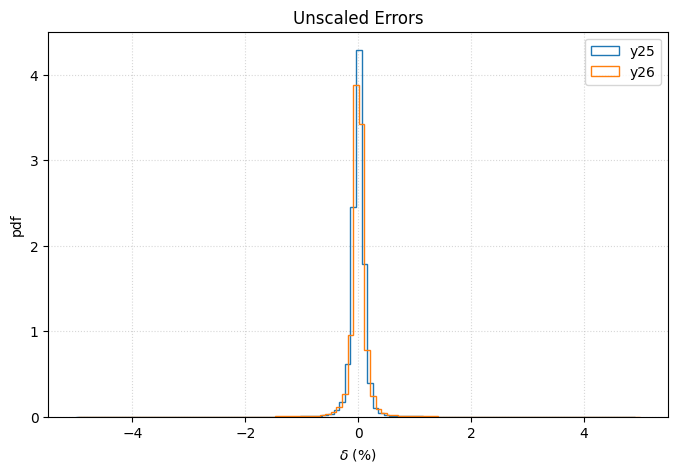

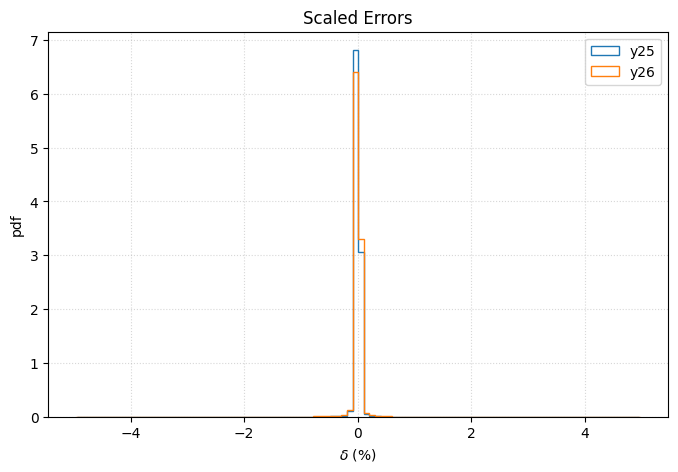

In [22]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=0
)

# Eval code

# Error plots 

## h2 real and imaginary

In [20]:
# df_h2 = pd.read_csv('../models/skip-light-torch-4D-y5_y6-fe15fc3c--13-29-leaky_relu-1024-adam-exp-schedule-mse-val_mse-96.667286-99.840031/test-results-fe15fc3c-96.667286-99.840031.csv')
df_h2 = df_pred

In [22]:
df_pred

,x1,x2,x3,x4,y25_scaled,y26_scaled,y25,y26,y25_scaled_pred,y26_scaled_pred,y25_pred,y26_pred,scaled_delta_y25,scaled_delta_y26,delta_y25,delta_y26
0,0.001656,0.771066,0.436337,0.521262,-5.666455,5.701340,-288.008074,298.268286,-5.666381,5.702377,-287.986764,298.578633,-0.001301,0.018180,-0.007399,0.104050
1,0.002124,0.581542,0.511984,0.521890,-5.541317,5.578936,-254.013678,263.789758,-5.541427,5.579581,-254.041591,263.960553,0.001975,0.011558,0.010989,0.064747
2,0.002743,0.463915,0.528051,0.508386,-5.326274,5.365031,-204.670278,212.797939,-5.326005,5.365030,-204.614850,212.797606,-0.005061,-0.000029,-0.027082,-0.000157
3,0.003052,0.961049,0.543344,0.505631,-5.123134,5.148738,-166.860542,171.214053,-5.122797,5.150123,-166.804144,171.452737,-0.006559,0.026900,-0.033799,0.139407
4,0.003572,0.361104,0.520037,0.524839,-5.040506,5.079077,-153.548209,159.625778,-5.041166,5.080721,-153.650185,159.889945,0.013086,0.032354,0.066413,0.165492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,0.502007,0.167341,0.524737,0.520739,-3.751843,5.047873,-41.599529,154.690932,-3.752100,5.047505,-41.610478,154.633688,0.006850,-0.007285,0.026320,-0.037005
499708,0.502228,0.420521,0.513963,0.519415,-3.520024,5.201461,-32.785241,180.537339,-3.520401,5.201983,-32.797988,180.632091,0.010716,0.010032,0.038879,0.052483
499709,0.502403,0.555022,0.528000,0.677927,-3.632100,5.361967,-36.792084,212.143726,-3.631617,5.362234,-36.773846,212.200737,-0.013289,0.004988,-0.049568,0.026873
499710,0.502513,0.233200,0.525068,0.503832,-3.602574,5.081265,-35.692576,159.977516,-3.603016,5.081140,-35.708768,159.957399,0.012246,-0.002460,0.045365,-0.012575


In [36]:
pred = df_pred["y26_scaled_pred"]
test = df_pred["y26_scaled"]
1 - ((pred - test)/test).abs().mean()

-0.9441725920990833

In [67]:
1 - ((pred - test)/(test + 1e-5)).abs().mean()

0.9916079828204297

In [75]:
df_temp = df_pred.sort_values(by='scaled_delta_y26', key=lambda x: x.abs(), ascending=False).iloc[2:]
temp_pred = df_temp["y26_scaled_pred"]
temp_test = df_temp["y26_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()


0.9966867682220568

In [80]:
col = df_pred['scaled_delta_y26']

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_temp = df_pred[(col >= lower) & (col <= upper)]
# df_temp = df_pred.sort_values(by='scaled_delta_y26', key=lambda x: x.abs(), ascending=False).iloc[2:]
temp_pred = df_temp["y26_scaled_pred"]
temp_test = df_temp["y26_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.9998872694053694

In [84]:
from scipy.stats import zscore

z = zscore(df_pred['scaled_delta_y26'])

df_temp = df_pred[abs(z) < 3]

# df_temp = df_pred[(col >= lower) & (col <= upper)]
# df_temp = df_pred.sort_values(by='scaled_delta_y26', key=lambda x: x.abs(), ascending=False).iloc[2:]
temp_pred = df_temp["y26_scaled_pred"]
temp_test = df_temp["y26_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.9966867682220568

In [85]:
lower = df_pred['scaled_delta_y26'].quantile(0.01)
upper = df_pred['scaled_delta_y26'].quantile(0.99)

df_temp = df_pred[
    (df_pred['scaled_delta_y26'] >= lower) &
    (df_pred['scaled_delta_y26'] <= upper)
]

temp_pred = df_temp["y26_scaled_pred"]
temp_test = df_temp["y26_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.9998274942819451

In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(
        df_pred.sort_values(
            by='scaled_delta_y26',
            key=lambda x: x.abs(),
            ascending=False
        )
    )

In [51]:
with pd.option_context('display.max_rows', None):
    display(
        df_pred.sort_values(by='scaled_delta_y26', key=lambda x: x.abs(), ascending=False).head(100)
    )


,x1,x2,x3,x4,y25_scaled,y26_scaled,y25,y26,y25_scaled_pred,y26_scaled_pred,y25_pred,y26_pred,scaled_delta_y25,scaled_delta_y26,delta_y25,delta_y26
316346,0.417806,1.224739e-06,0.431139,0.759019,-0.000181,8.175398e-09,-0.000181,8.175398e-09,-0.008714,-0.007854,-0.008752,-0.007884,4722.257376,-9.606308e+07,4742.891727,-9.644129e+07
24716,0.325617,2.691948e-07,0.536530,0.514836,-0.000003,4.695556e-07,-0.000003,4.695557e-07,0.004306,0.004339,0.004315,0.004349,-126077.665839,9.239924e+05,-126349.076187,9.259999e+05
421982,0.402873,6.602171e-06,0.514667,0.508391,-0.001916,-7.109541e-06,-0.001918,-7.109566e-06,-0.005331,-0.004198,-0.005345,-0.004207,178.205521,5.895036e+04,178.681231,5.907428e+04
497915,0.411605,7.243130e-06,0.563698,0.495425,-0.002554,-3.107549e-05,-0.002557,-3.107597e-05,-0.001342,-0.005782,-0.001343,-0.005799,-47.456863,1.850679e+04,-47.488702,1.856039e+04
270646,0.405246,1.113341e-05,0.615729,0.506799,-0.003932,-1.329507e-05,-0.003940,-1.329516e-05,-0.007827,-0.002148,-0.007857,-0.002150,99.055597,1.605635e+04,99.443990,1.607360e+04
245168,0.151820,1.198479e-06,0.524783,0.521728,-0.000003,1.819793e-06,-0.000003,1.819795e-06,0.000280,-0.000161,0.000280,-0.000161,-8402.320158,-8.966782e+03,-8403.468593,-8.967490e+03
390682,0.374474,5.354664e-06,0.478890,0.529459,-0.000788,2.644248e-05,-0.000788,2.644283e-05,-0.001349,-0.001105,-0.001350,-0.001105,71.264983,-4.278398e+03,71.313073,-4.280652e+03
438941,0.480303,1.452394e-06,0.503161,0.433968,-0.001446,-1.000228e-04,-0.001447,-1.000278e-04,-0.044783,-0.003970,-0.045801,-0.003977,2997.537875,3.868699e+03,3065.654583,3.876387e+03
438063,0.433876,8.077954e-04,0.518053,0.439602,-1.743147,6.963536e-04,-4.715303,6.965961e-04,-1.751441,0.015156,-4.762900,0.015272,0.475784,2.076509e+03,1.009428,2.092323e+03
334935,0.102253,2.643109e-05,0.519032,0.502656,-0.000230,1.567409e-04,-0.000230,1.567532e-04,0.001626,-0.002805,0.001628,-0.002809,-806.120493,-1.889395e+03,-806.613637,-1.891767e+03


In [28]:
100 - df_h2["delta_y26"].abs().mean()

-95.26364434155298

In [29]:
df = df_h2
df[["y26", "y26_pred"]]

,y26,y26_pred
0,298.268286,298.578633
1,263.789758,263.960553
2,212.797939,212.797606
3,171.214053,171.452737
4,159.625778,159.889945
...,...,...
499707,154.690932,154.633688
499708,180.537339,180.632091
499709,212.143726,212.200737
499710,159.977516,159.957399


In [31]:
(df["y26"] - df["y26_pred"]).abs().mean()

0.4058021137357296

In [21]:
df26 = df[['y26', 'y26_pred']].copy()

# compute the raw difference (residual)
df26['diff'] = df26['y26'] - df26['y26_pred']

# compute percent‐error delta
df26['delta_y26'] = df26['diff'] / df26['y26'] * 100

# show the first few rows
df26

,y18,y18_pred,diff,delta_y18
0,-240.569423,-240.051323,-0.518100,0.215364
1,182.917455,183.183028,-0.265573,-0.145187
2,-133.756088,-134.064574,0.308486,-0.230633
3,152.983583,152.784979,0.198604,0.129820
4,43.834251,43.772769,0.061482,0.140260
...,...,...,...,...
499707,-0.575642,-0.567680,-0.007962,1.383179
499708,-0.049279,-0.047631,-0.001648,3.345074
499709,0.004035,0.005220,-0.001186,-29.388779
499710,-0.003356,-0.003423,0.000066,-1.978665


In [22]:
df18

,y18,y18_pred,diff,delta_y18
0,-240.569423,-240.051323,-0.518100,0.215364
1,182.917455,183.183028,-0.265573,-0.145187
2,-133.756088,-134.064574,0.308486,-0.230633
3,152.983583,152.784979,0.198604,0.129820
4,43.834251,43.772769,0.061482,0.140260
...,...,...,...,...
499707,-0.575642,-0.567680,-0.007962,1.383179
499708,-0.049279,-0.047631,-0.001648,3.345074
499709,0.004035,0.005220,-0.001186,-29.388779
499710,-0.003356,-0.003423,0.000066,-1.978665


In [23]:
pd.set_option('display.float_format', '{:.20f}'.format)
print(df18.sort_values('delta_y18', ascending=False)[0:10000])
#pd.reset_option('display.float_format')

                           y18                y18_pred  \
394627 -0.00000001415130412852  0.00023894021163783918   
83872  -0.00000005830274574237  0.00065944417556695889   
235088 -0.00000016518712797620  0.00067780894645830259   
447066  0.00000012136282379061 -0.00025519584472122325   
469834 -0.00000030725730404413  0.00048364667162603681   
...                        ...                     ...   
188542 -0.01956421279220776910 -0.01459324788284233065   
470137 -0.00106687172047337242 -0.00079585860744790793   
129780 -0.00178780378193366118 -0.00133390527583543417   
166947 -0.00348851273939487783 -0.00260301981407939920   
68612  -0.00399289840629535320 -0.00297943990445093121   

                          diff                    delta_y18  
394627 -0.00023895436294196770 1688567.78691105055622756481  
83872  -0.00065950247831270126 1131168.81531955185346305370  
235088 -0.00067797413358627878  410427.94429114111699163914  
447066  0.00025531720754501386  210375.1376002331671770

In [24]:
df18['abs_delta_y18'] = df18['delta_y18'].abs()
df18.reindex(df18['abs_delta_y18'].sort_values(ascending=False).index)[:20]

,y18,y18_pred,diff,delta_y18,abs_delta_y18
394627,-0.00000001415130412852,0.00023894021163783918,-0.00023895436294196770,1688567.78691105055622756481,1688567.78691105055622756481
174349,0.00000004445999479685,0.00066421033443209154,-0.00066416587443729469,-1493850.54467957490123808384,1493850.54467957490123808384
83872,-0.00000005830274574237,0.00065944417556695889,-0.00065950247831270126,1131168.81531955185346305370,1131168.81531955185346305370
454745,0.00000014133795644966,0.00102782720519556392,-0.00102768586723911426,-727112.44244226522278040648,727112.44244226522278040648
129262,0.00000014186663577220,0.00083006432833476751,-0.00082992246169899531,-585001.86261666985228657722,585001.86261666985228657722
265458,0.00000029966616921229,0.00146632703640592332,-0.00146602737023671104,-489220.17927160806721076369,489220.17927160806721076369
167526,0.00000017351899472828,0.00075735430414192173,-0.00075718078514719345,-436367.66472332144621759653,436367.66472332144621759653
235088,-0.00000016518712797620,0.00067780894645830259,-0.00067797413358627878,410427.94429114111699163914,410427.94429114111699163914
447066,0.00000012136282379061,-0.00025519584472122325,0.00025531720754501386,210375.13760023316717706621,210375.13760023316717706621
68210,0.00000030904595327286,0.00063966365080325716,-0.00063935460484998430,-206880.10895437828730791807,206880.10895437828730791807


In [25]:
df18.describe()

,y18,y18_pred,diff,delta_y18,abs_delta_y18
count,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000
mean,-0.09873022270206330275,-0.12681226991611474486,0.02808204721405149762,-2.48800281267444178823,33.63663255878972790924
std,116.53897857208340838042,116.32263826186792243789,6.31436787665629228883,4040.77896757665257609915,4040.63973024893175534089
min,-2711.30996042442302496056,-893.50647732938114131684,-2929.19046607193013187498,-1493850.54467957490123808384,0.00000000503477923354
25%,-17.18636083145364068514,-17.16490856342559112591,-0.02268088213931152008,-0.17248087157636082800,0.12681836325446588232
50%,-0.00001801405742440920,0.00035708719580906934,-0.00073072149663822028,0.09370807789880036820,0.29636656751019224698
75%,17.36856412752658940235,17.38148566056654686918,0.03772969782054147458,0.41619209980885235600,0.72006481672151223528
max,1164.17193049737852561520,802.89582431011319840763,1320.64006771039953491709,1688567.78691105055622756481,1688567.78691105055622756481


In [26]:
df18.abs()[20000:]["delta_y18"].abs().mean()

34.61662380223456

In [27]:
df18["y18"]

0        -240.56942296808205128400
1         182.91745493979775005755
2        -133.75608777624688627839
3         152.98358268819541194716
4          43.83425116481588901252
                    ...           
499707     -0.57564244598592373414
499708     -0.04927932203213103435
499709      0.00403454508865053185
499710     -0.00335636972818065260
499711      0.48196748411372070109
Name: y18, Length: 499712, dtype: float64

In [28]:
(df18["y18"] > 1e-3).sum()

241238

In [29]:
100 - df18["delta_y18"][df18["y18"] > 1e-3].abs().mean()

98.23394397531456

In [30]:
100 - df18["delta_y18"].abs().sort_values(ascending=False)[10:-1].mean()

81.12940249787744

In [31]:
df17 = df[['y17', 'y17_pred']].copy()

# compute the raw difference (residual)
df17['diff'] = df17['y17'] - df17['y17_pred']

# compute percent‐error delta
df17['delta_y17'] = df17['diff'] / df17['y17'] * 100

# show the first few rows
df17

,y17,y17_pred,diff,delta_y17
0,230.24095327649700948314,229.68272031454282000595,0.55823296195418947718,0.24245598101038348671
1,-174.14936483868277150577,-174.27503000777610964178,0.12566516909333813601,-0.07215941855989178866
2,128.71566947862038432504,129.34622629493898671171,-0.63055681631860238667,-0.48988349194216607163
3,-144.44316263615843354273,-144.83107975901265263019,0.38791712285421908746,-0.26856039135016274155
4,-42.23305095611935655597,-42.26762298604469947350,0.03457202992534291752,-0.08186012883905467719
...,...,...,...,...
499707,-1.59364159203566480016,-1.58430377807099098675,-0.00933781396467381342,0.58594190885454988660
499708,-0.49541102241317958033,-0.49480168655596390437,-0.00060933585721567596,0.12299602343273693950
499709,0.14287281616268288076,0.14178039852630486273,0.00109241763637801803,0.76460845787076170410
499710,-0.10359255108209897145,-0.10366034706768956219,0.00006779598559059075,-0.06544484606510095337


In [32]:
df17.reindex(df17['delta_y17'].abs().sort_values(ascending=False).index)[:10]

,y17,y17_pred,diff,delta_y17
24584,-0.00003467135703072444,0.00498535539257560778,-0.00502002674960633222,14478.88741463962651323527
374901,0.00120695153156180623,-0.14424186179170872535,0.14544881332327053158,12050.92412742195665487088
283910,0.00031364714112225300,-0.02748094384654620193,0.02779459098766845493,8861.73898739115611533634
203807,-0.00003595212308837858,0.00302135446686380149,-0.00305730658995218008,8503.82766669055308739189
280351,-0.00001119364520008048,0.00085935874779519139,-0.00087055239299527187,7777.20195195228006923571
313858,0.00026781025096944688,-0.01874417227389302276,0.01901198252486246965,7099.04959053693983150879
316548,0.00009155293802631803,0.00642897738031655841,-0.00633742444229024038,-6922.14207311235441011377
150347,-0.00013212699465903199,0.00700159285179657864,-0.00713371984645561064,5399.13880949532449449180
293467,-0.01514703784720450308,0.71232083775749877042,-0.72746787560470327350,4802.70718897664119140245
285650,0.00048336262862491708,0.01987897839856977988,-0.01939561576994486281,-4012.64281128270704357419


In [33]:
df_h2["delta_y17"]

0        -0.24245598101038348671
1         0.07215941855989178866
2         0.48988349194216607163
3         0.26856039135016274155
4         0.08186012883905467719
                   ...          
499707   -0.58594190885454988660
499708   -0.12299602343273693950
499709   -0.76460845787076170410
499710    0.06544484606510095337
499711   -0.04508626402890548307
Name: delta_y17, Length: 499712, dtype: float64

In [34]:
df_h2.describe()

,x1,x2,x3,x4,y17_scaled,y18_scaled,y17,y18,y17_scaled_pred,y18_scaled_pred,y17_pred,y18_pred,scaled_delta_y17,scaled_delta_y18,delta_y17,delta_y18
count,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000
mean,0.49925700527143107577,0.49946930487487523065,0.49959831168449431171,0.49919920875870060772,-0.00063862245736353337,-0.00028417318975051205,0.20054609594388358995,-0.09873022270206330275,0.00010149867027560273,0.00005157751596282557,0.23204444376973026865,-0.12681226991611474486,-0.12163726002215985433,2.49118691170428352422,-0.09468110657727639434,2.48800281267444178823
std,0.28840179849242147947,0.28869124178696292660,0.28880734299482851979,0.28830808721535133854,2.97146818682792446253,3.45657781126697116747,97.36793468266688478252,116.53897857208340838042,2.97149687051068145394,3.45625517262585368883,94.84314354035171845680,116.32263826186792243789,42.19201708298916742024,4039.63342845237457368057,43.44526057607399849303,4040.77896757665257609915
min,0.00000014615929290980,0.00000367488420800000,0.00000149422516200000,0.00000000188715600000,-8.85950544622724400767,-7.90555593472132756006,-7039.99973038681309844833,-2711.30996042442302496056,-7.56832198674903899871,-6.79627214420749847790,-1934.88910699069856491406,-893.50647732938114131684,-14443.41280927420484658796,-1688366.10955853876657783985,-14478.88741463962651323527,-1688567.78691105055622756481
25%,0.24945223390406567887,0.24947608692559200549,0.24909028326087523375,0.24961780091905599877,-2.25544151368222989262,-2.90067190827180088064,-8.53950420214541061625,-17.18636083145364068514,-2.25416087069196358073,-2.89949163199179693606,-8.52729532227355946361,-17.16490856342559112591,-0.12329655026149441421,-0.15399419605298492186,-0.32061424542041772057,-0.41619209980885235600
50%,0.49907971771260983829,0.49964960652232598415,0.49989675755400297952,0.49843940292516353274,-0.00236280034877890156,-0.00001801389517317410,-0.00236559396370505937,-0.00001801405742440920,-0.00173923365152527359,0.00035702345533277467,-0.00174074699927062593,0.00035708719580906934,-0.00436364718585258854,-0.02392907118006050438,-0.01293069133711112484,-0.09370807789880036820
75%,0.74849174774416449285,0.74942372292592418503,0.74936844710294003846,0.74833402423672923387,2.25359217770292552530,2.91064073139427925696,8.52187875687064888552,17.36856412752658940235,2.25450433038581010692,2.91134394307412947001,8.53056812764425309581,17.38148566056654686918,0.09031609678747315462,0.04609591375132183338,0.27139102433993378405,0.17248087157636082800
max,0.99999424527251590256,0.99999788764426100762,0.99999874299348801010,0.99999812827165501794,8.58428467956449026133,7.06062393493704565373,5345.96655256507528974907,1164.17193049737852561520,7.99361758721584259035,6.68946968903023098107,2960.99286866213287794380,802.89582431011319840763,6899.98617364248912053881,1493354.64877252606675028801,6922.14207311235441011377,1493850.54467957490123808384


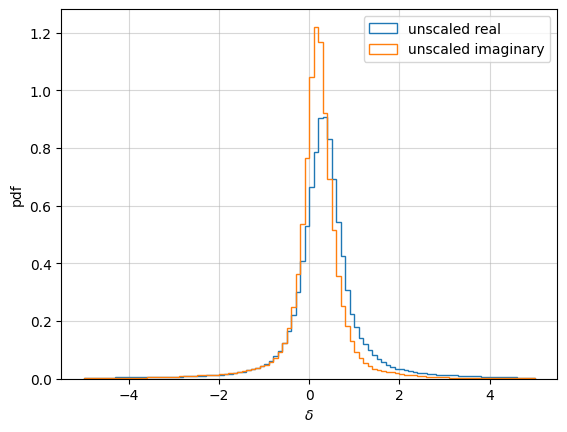

In [27]:
plt.hist(df_h2[abs(df_h2.delta_y5) < 5].delta_y5, bins=100, histtype='step', label='unscaled real', density=True)
plt.hist(df_h2[abs(df_h2.delta_y6) < 5].delta_y6, bins=100, histtype='step', label='unscaled imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

In [36]:
df_h2[abs(df_h2.scaled_delta_y17) < 5].scaled_delta_y17

0        -0.04440178269978333619
1         0.01388438154246551121
2         0.09967005896512916296
3         0.05348801679989620417
4         0.02122195054123778707
                   ...          
499707   -0.37843966718479149502
499708   -0.10128042020253724687
499709   -0.71609470770447269938
499710    0.06232087426649454004
499711   -0.02978108146468904857
Name: scaled_delta_y17, Length: 490654, dtype: float64

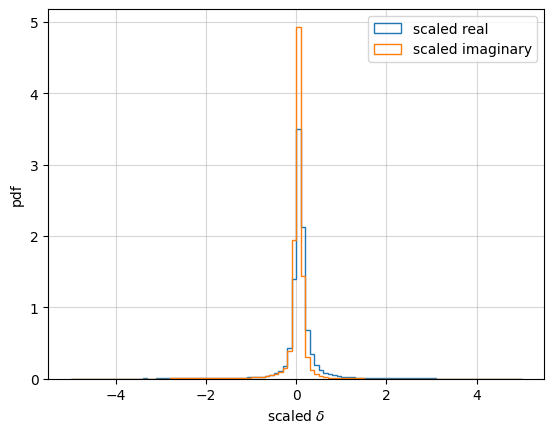

In [28]:
plt.hist(df_h2[abs(df_h2.scaled_delta_y5) < 5].scaled_delta_y5, bins=100, histtype='step', label='scaled real', density=True)
plt.hist(df_h2[abs(df_h2.scaled_delta_y6) < 5].scaled_delta_y6, bins=100, histtype='step', label='scaled imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'scaled $\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

In [29]:
df_h2

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0.001656,0.771066,0.436337,0.521262,5.032712,-5.070183,152.348295,-158.203404,5.037163,-5.077358,153.032397,-159.349856,0.088445,0.141521,0.449038,0.724670
1,0.002124,0.581542,0.511984,0.521890,5.164520,-5.203726,173.953388,-180.948847,5.163800,-5.204524,173.827608,-181.094216,-0.013926,0.015347,-0.072307,0.080337
2,0.002743,0.463915,0.528051,0.508386,4.962266,-5.001355,141.917239,-147.614354,4.960350,-4.998779,141.643742,-147.232091,-0.038601,-0.051496,-0.192716,-0.258960
3,0.003052,0.961049,0.543344,0.505631,3.579522,-3.607909,34.856411,-35.888819,3.580510,-3.612176,34.891835,-36.046573,0.027586,0.118277,0.101628,0.439562
4,0.003572,0.361104,0.520037,0.524839,4.504727,-4.542012,89.443672,-92.879537,4.505312,-4.547334,89.496578,-93.380452,0.012982,0.117162,0.059151,0.539316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,0.502007,0.167341,0.524737,0.520739,-4.328688,-4.410747,-74.844741,-81.330981,-4.324564,-4.405729,-74.532576,-80.918821,-0.095279,-0.113784,-0.417084,-0.506769
499708,0.502228,0.420521,0.513963,0.519415,-3.474266,-3.918505,-31.274130,-49.325172,-3.474761,-3.921061,-31.290113,-49.453942,0.014250,0.065216,0.051105,0.261062
499709,0.502403,0.555022,0.528000,0.677927,-3.237579,-4.065832,-24.471969,-57.313389,-3.239206,-4.067871,-24.513451,-57.432402,0.050259,0.050146,0.169505,0.207653
499710,0.502513,0.233200,0.525068,0.503832,-4.021274,-4.145710,-54.772100,-62.162472,-4.023046,-4.141329,-54.871030,-61.886361,0.044072,-0.105676,0.180621,-0.444176
